In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [2]:
coupons = pd.read_csv("data_raw/coupons.csv")
sessions = pd.read_csv("data_raw/sessions.csv")
orders = pd.read_csv("data_raw/orders.csv")
order_items = pd.read_csv("data_raw/order_items.csv")
payments = pd.read_csv("data_raw/payments.csv")
shipments = pd.read_csv("data_raw/shipments.csv")
refunds = pd.read_csv("data_raw/refunds.csv")
products = pd.read_json("data_raw/products.json", orient="records")
users = pd.read_csv("data_raw/users.csv")

In [3]:
for df in [orders, order_items, payments, shipments, users, refunds, products]:
    df.columns = df.columns.str.lower().str.strip()


In [4]:
orders = orders.drop_duplicates(subset="order_id", keep="last")
orders = orders.dropna(subset=["user_id"])
orders["device"]           = orders["device"].fillna("unknown")
orders["shipping_pincode"] = orders["shipping_pincode"].fillna("000000")
orders["coupon_id"]        = orders["coupon_id"].fillna("NO_COUPON")
orders["order_ts"]         = pd.to_datetime(orders["order_ts"], errors="coerce")

for col in ["channel", "device", "payment_method", "order_status"]:
    orders[col] = orders[col].str.strip().str.lower()

orders["device"]    = orders["device"].replace("unkown", "unknown")
orders["city_tier"] = orders["city_tier"].astype(str).str.strip()
orders["city_tier"] = orders["city_tier"].map(
    {"1.0":"tier1", "2.0":"tier2", "3.0":"tier3"}
)

print("Orders cleaned:", orders.shape)

Orders cleaned: (3951, 18)


In [5]:
order_items = order_items.merge(
    products[["product_id","category"]], on="product_id", how="left"
)
top_cat = (order_items
    .groupby(["order_id","category"])["quantity"].sum()
    .reset_index()
    .sort_values("quantity", ascending=False)
    .drop_duplicates("order_id")[["order_id","category"]]
    .rename(columns={"category":"top_category"})
)
item_agg = order_items.groupby("order_id").agg(
    item_count  = ("product_id","count"),
    total_qty   = ("quantity","sum"),
    order_value = ("unit_price","sum")
).reset_index().merge(top_cat, on="order_id", how="left")

orders = orders.merge(item_agg, on="order_id", how="left")
print("Items merged:", orders.shape)

Items merged: (3951, 22)


In [6]:
users["signup_date"] = pd.to_datetime(users["signup_date"], errors="coerce")
orders = orders.merge(
    users[["user_id","signup_date","segment","risk_profile"]],
    on="user_id", how="left"
)
orders["new_user_flag"] = (
    (orders["order_ts"] - orders["signup_date"]).dt.days <= 7
).astype(int)
print("Users merged:", orders.shape)


Users merged: (3951, 26)


In [7]:
payments["payment_status"] = payments["payment_status"].str.strip().str.lower()
payments = payments.sort_values(["order_id","attempt_no"])

def count_fails(group):
    fails = 0
    for status in group["payment_status"]:
        if status == "failed":
            fails += 1
        elif status == "success":
            break
    return fails

pay_agg = payments.groupby("order_id").apply(count_fails).reset_index()
pay_agg.columns = ["order_id","payment_fail_count"]
orders = orders.merge(pay_agg, on="order_id", how="left")
orders["payment_fail_count"] = orders["payment_fail_count"].fillna(0)
print("Payments merged:", orders.shape)


Payments merged: (3951, 27)


In [8]:
shipments["shipment_status"] = shipments["shipment_status"].str.strip().str.lower()
shipments["rto_flag"] = (shipments["shipment_status"] == "rto").astype(int)
shipments = shipments.drop_duplicates()
shipments = shipments.sort_values("shipped_ts", ascending=False)
shipments = shipments.drop_duplicates(subset="order_id", keep="first")
orders = orders.merge(
    shipments[["order_id","rto_flag"]], on="order_id", how="left"
)
orders["rto_flag"] = orders["rto_flag"].fillna(0)
print("Shipments merged:", orders.shape)

Shipments merged: (3951, 28)


In [9]:
refund_agg = refunds.groupby("order_id").agg(
    refund_flag   = ("refund_amount","count"),
    refund_amount = ("refund_amount","sum")
).reset_index()
refund_agg["refund_flag"] = (refund_agg["refund_flag"] > 0).astype(int)
orders = orders.merge(refund_agg, on="order_id", how="left")
orders["refund_flag"]   = orders["refund_flag"].fillna(0)
orders["refund_amount"] = orders["refund_amount"].fillna(0)
print("Refunds merged:", orders.shape)


Refunds merged: (3951, 30)


In [11]:
from scipy import stats
orders["discount_pct_check"] = (
    orders["discount_amount"] / orders["gross_amount"] * 100
)
orders["high_discount_flag"] = (orders["discount_pct_check"] > 19).astype(int)
orders["cod_flag"]           = (orders["payment_method"] == "cod").astype(int)
orders["order_hour"]         = orders["order_ts"].dt.hour
orders["late_night_flag"]    = (
    (orders["order_hour"] >= 23) | (orders["order_hour"] <= 4)
).astype(int)
orders["payment_fail_flag"]  = (orders["payment_fail_count"] >= 2).astype(int)

qty_mean = orders["total_qty"].mean()
qty_std  = orders["total_qty"].std()
orders["qty_outlier_flag"]   = (
    orders["total_qty"] > qty_mean + 3*qty_std
).astype(int)

orders["order_value_zscore"] = stats.zscore(orders["gross_amount"].fillna(0))
orders["high_value_flag"]    = (
    orders["order_value_zscore"].abs() > 2.5
).astype(int)

device_user_count = (orders.groupby("device_id")["user_id"]
    .nunique().reset_index()
    .rename(columns={"user_id":"device_user_count"}))
orders = orders.merge(device_user_count, on="device_id", how="left")
orders["device_reuse_flag"]  = (orders["device_user_count"] >= 3).astype(int)

print("Risk signals built")

Risk signals built


In [ ]:
signal_cols = [
    "high_discount_flag", "cod_flag", "late_night_flag",
    "payment_fail_flag", "new_user_flag", "rto_flag",
    "refund_flag", "qty_outlier_flag", "high_value_flag",
    "device_reuse_flag"
]
orders["signal_count"] = orders[signal_cols].sum(axis=1)
orders["risk_band"]    = pd.cut(
    orders["signal_count"],
    bins=[-1, 1, 2, 6],
    labels=["Low","Medium","High"]
)

In [38]:
signal_labels = {
    "high_discount_flag" : "High Discount",
    "cod_flag"           : "Cash on Delivery",
    "late_night_flag"    : "Late Night Order",
    "payment_fail_flag"  : "Card Testing",
    "new_user_flag"      : "New User",
    "rto_flag"           : "RTO History",
    "refund_flag"        : "Refund History",
    "qty_outlier_flag"   : "Unusual Quantity",
    "high_value_flag"    : "Abnormal Order Value",
    "device_reuse_flag"  : "Device Shared 3+ Accounts",
}

def get_top_reasons(row):
    triggered = [
        label for signal, label
        in signal_labels.items()
        if row[signal] == 1
    ]
    return " | ".join(triggered[:3])

def recommend_action(row):
    if row["signal_count"] >= 4:
        return "Auto-Cancel"
    elif row["signal_count"] >= 3:
        return "Hold + Manual Review"
    elif row["cod_flag"] == 1 and row["signal_count"] >= 2:
        return "Call Verification"
    else:
        return "Flag for Review"

orders["top_risk_reasons"]   = orders.apply(get_top_reasons, axis=1)
orders["recommended_action"] = orders.apply(recommend_action, axis=1)

In [ ]:
import os   

os.makedirs("data", exist_ok=True)

# Output 1
orders.to_csv("data/fact_orders_enriched.csv", index=False)

# Output 2 - Investigation Queue
investigation_queue = (
    orders[orders["risk_band"] == "High"][[
        "order_id","user_id","risk_band","signal_count",
        "top_risk_reasons","recommended_action",
        "gross_amount","payment_method","city_tier"
    ]]
    .sort_values("signal_count", ascending=False)
    .reset_index(drop=True)
)
investigation_queue.to_csv("data/investigation_queue.csv", index=False)

print("\nALL OUTPUTS SAVED")
print("fact_orders_enriched:", orders.shape)
print("investigation_queue:", investigation_queue.shape)
print("\nRisk Band Distribution:")
print(orders["risk_band"].value_counts())


ALL OUTPUTS SAVED
fact_orders_enriched: (3951, 62)
investigation_queue: (262, 9)

Risk Band Distribution:
risk_band
Low       2996
Medium     693
High       262
Name: count, dtype: int64


Output 2

In [ ]:
# Add this as a new cell AFTER your ETL cell
orders["week_start"] = orders["order_ts"].dt.to_period("W").dt.start_time

weekly = orders.groupby(["user_id","week_start"]).agg(
    orders_count          = ("order_id","count"),
    net_revenue           = ("net_amount","sum"),
    refunds_count         = ("refund_flag","sum"),
    refund_amount         = ("refund_amount","sum"),
    coupon_orders_count   = ("coupon_id", lambda x: (x != "NO_COUPON").sum()),
    avg_discount_pct      = ("discount_pct_check","mean"),
    cod_orders_count      = ("cod_flag","sum"),
    rto_count             = ("rto_flag","sum"),
    payment_failures_count= ("payment_fail_count","sum"),
    risk_score_avg        = ("signal_count","mean"),
).reset_index()

weekly.to_csv("data/fact_user_risk_weekly.csv", index=False)
print("Weekly saved:", weekly.shape)
print(weekly.head(3))

Weekly saved: (3816, 12)
   user_id week_start  orders_count  net_revenue  refunds_count  \
0  U000001 2025-09-22             1      4358.65            0.0   
1  U000001 2025-11-24             1       637.09            0.0   
2  U000001 2026-01-19             1      6498.72            0.0   

   refund_amount  coupon_orders_count  avg_discount_pct  cod_orders_count  \
0            0.0                    0               0.0                 0   
1            0.0                    0               0.0                 0   
2            0.0                    0               0.0                 0   

   rto_count  payment_failures_count  risk_score_avg  
0        0.0                       0             0.0  
1        0.0                       0             0.0  
2        1.0                       0             1.0  


In [ ]:
# How much money is at risk?
total_refund_loss = orders["refund_amount"].sum()
total_orders_value = orders["net_amount"].sum()
high_risk_value = orders[orders["risk_band"]=="High"]["gross_amount"].sum()

print(f"Total Revenue        : ₹{total_orders_value:,.0f}")
print(f"Total Refund Loss    : ₹{total_refund_loss:,.0f}")
print(f"Refund Loss %        : {total_refund_loss/total_orders_value*100:.2f}%")
print(f"High Risk Order Value: ₹{high_risk_value:,.0f}")
print(f"High Risk Order Count: {len(orders[orders['risk_band']=='High'])}")

Total Revenue        : ₹24,601,829
Total Refund Loss    : ₹1,579,995
Refund Loss %        : 6.42%
High Risk Order Value: ₹2,039,303
High Risk Order Count: 262


In [ ]:
cod_analysis = orders.groupby("cod_flag").agg(
    order_count   = ("order_id", "count"),
    refund_rate   = ("refund_flag", "mean"),
    rto_rate      = ("rto_flag", "mean"),
    avg_risk      = ("signal_count", "mean"),
    total_loss    = ("refund_amount", "sum")
).reset_index()

cod_analysis["payment_type"] = cod_analysis["cod_flag"].map(
    {0:"Prepaid", 1:"COD"}
)
print(cod_analysis[["payment_type","order_count",
                     "refund_rate","rto_rate","avg_risk","total_loss"]])

  payment_type  order_count  refund_rate  rto_rate  avg_risk  total_loss
0      Prepaid         2824     0.104816  0.054178  0.665014  1579994.99
1          COD         1127     0.147294  0.117125  1.685004        0.00


In [ ]:
user_analysis = orders.groupby("new_user_flag").agg(
    order_count   = ("order_id", "count"),
    refund_rate   = ("refund_flag", "mean"),
    avg_discount  = ("discount_pct_check", "mean"),
    avg_risk      = ("signal_count", "mean"),
    total_loss    = ("refund_amount", "sum")
).reset_index()

user_analysis["user_type"] = user_analysis["new_user_flag"].map(
    {0:"Returning", 1:"New"}
)
print(user_analysis[["user_type","order_count",
                      "refund_rate","avg_discount","avg_risk","total_loss"]])

   user_type  order_count  refund_rate  avg_discount  avg_risk  total_loss
0  Returning         3722      0.11741      1.282752  0.896830  1530037.50
1        New          229      0.10917      1.111814  1.917031    49957.49


In [ ]:
tier_analysis = orders.groupby("city_tier").agg(
    order_count = ("order_id", "count"),
    refund_rate = ("refund_flag", "mean"),
    rto_rate    = ("rto_flag", "mean"),
    avg_risk    = ("signal_count", "mean"),
    total_loss  = ("refund_amount", "sum")
).reset_index()

print(tier_analysis)

  city_tier  order_count  refund_rate  rto_rate  avg_risk  total_loss
0     tier1         1175     0.112340  0.068085  0.958298   451019.77
1     tier2         2005     0.120200  0.075312  0.967082   813355.00
2     tier3          771     0.115435  0.070039  0.923476   315620.22


In [ ]:
cat_analysis = orders.groupby("top_category").agg(
    order_count = ("order_id", "count"),
    refund_rate = ("refund_flag", "mean"),
    avg_risk    = ("signal_count", "mean"),
    total_loss  = ("refund_amount", "sum")
).reset_index().sort_values("total_loss", ascending=False)

print(cat_analysis.head(7))

  top_category  order_count  refund_rate  avg_risk  total_loss
2  Electronics          626     0.135783  1.012780   561816.87
0       Beauty          557     0.134650  1.010772   287500.90
3      Fashion          695     0.110791  0.919424   272341.39
5         Home          731     0.105335  0.952120   192390.46
1        Books          455     0.123077  0.989011   113015.28
4      Grocery          601     0.098170  0.903494    92363.81
6       Sports          286     0.115385  0.881119    60566.28


In [ ]:
# Card testing pattern
card_testing = orders[orders["payment_fail_flag"] == 1]

print(f"Card testing orders  : {len(card_testing)}")
print(f"% of total orders    : {len(card_testing)/len(orders)*100:.1f}%")
print(f"Refund rate          : {card_testing['refund_flag'].mean()*100:.1f}%")
print(f"Avg order value      : ₹{card_testing['gross_amount'].mean():,.0f}")
print(f"Total loss           : ₹{card_testing['refund_amount'].sum():,.0f}")

# Which channel do card testers come from?
print("\nCard testing by channel:")
print(card_testing["channel"].value_counts())

# Which device?
print("\nCard testing by device:")
print(card_testing["device"].value_counts())

Card testing orders  : 302
% of total orders    : 7.6%
Refund rate          : 12.6%
Avg order value      : ₹5,349
Total loss           : ₹160,290

Card testing by channel:
channel
organic        83
search         77
paid_social    58
email          42
referral       42
Name: count, dtype: int64

Card testing by device:
device
web        168
mobile     133
unknown      1
Name: count, dtype: int64


In [ ]:
patterns_summary = pd.DataFrame([
    {
        "Pattern"        : "COD High RTO",
        "Orders"         : 1127,
        "Refund Rate"    : "14.7%",
        "Est Loss (₹)"   : "N/A (data gap)",
        "Concentration"  : "All tiers, mobile heavy",
        "Action"         : "OTP verification for COD > ₹1500"
    },
    {
        "Pattern"        : "Electronics Refund Abuse",
        "Orders"         : 626,
        "Refund Rate"    : "13.6%",
        "Est Loss (₹)"   : "₹5,61,817",
        "Concentration"  : "Tier2, returning users",
        "Action"         : "Manual review for electronics > ₹8000"
    },
    {
        "Pattern"        : "Card Testing",
        "Orders"         : 302,
        "Refund Rate"    : "12.6%",
        "Est Loss (₹)"   : "₹1,60,290",
        "Concentration"  : "Web + organic channel",
        "Action"         : "Block after 2 consecutive fails"
    },
    {
        "Pattern"        : "New User Promo Abuse",
        "Orders"         : 229,
        "Refund Rate"    : "10.9%",
        "Est Loss (₹)"   : "₹49,957",
        "Concentration"  : "New accounts, high risk score",
        "Action"         : "One coupon per device for new users"
    },
    {
        "Pattern"        : "Device Sharing (3+ accounts)",
        "Orders"         : 88,
        "Refund Rate"    : "unknown",
        "Est Loss (₹)"   : "unknown",
        "Concentration"  : "Same device_id multiple users",
        "Action"         : "Device fingerprint blocklist"
    },
])

print(patterns_summary.to_string(index=False))
patterns_summary.to_csv("data/fraud_patterns_summary.csv", index=False)
print("\nPatterns saved")

                     Pattern  Orders Refund Rate   Est Loss (₹)                 Concentration                                Action
                COD High RTO    1127       14.7% N/A (data gap)       All tiers, mobile heavy      OTP verification for COD > ₹1500
    Electronics Refund Abuse     626       13.6%      ₹5,61,817        Tier2, returning users Manual review for electronics > ₹8000
                Card Testing     302       12.6%      ₹1,60,290         Web + organic channel       Block after 2 consecutive fails
        New User Promo Abuse     229       10.9%        ₹49,957 New accounts, high risk score   One coupon per device for new users
Device Sharing (3+ accounts)      88     unknown        unknown Same device_id multiple users          Device fingerprint blocklist

Patterns saved


In [ ]:
device_reuse = orders[orders["device_reuse_flag"] == 1]
print(f"Device reuse orders : {len(device_reuse)}")
print(f"Refund rate         : {device_reuse['refund_flag'].mean()*100:.1f}%")
print(f"Total loss          : ₹{device_reuse['refund_amount'].sum():,.0f}")

Device reuse orders : 88
Refund rate         : 17.0%
Total loss          : ₹44,102


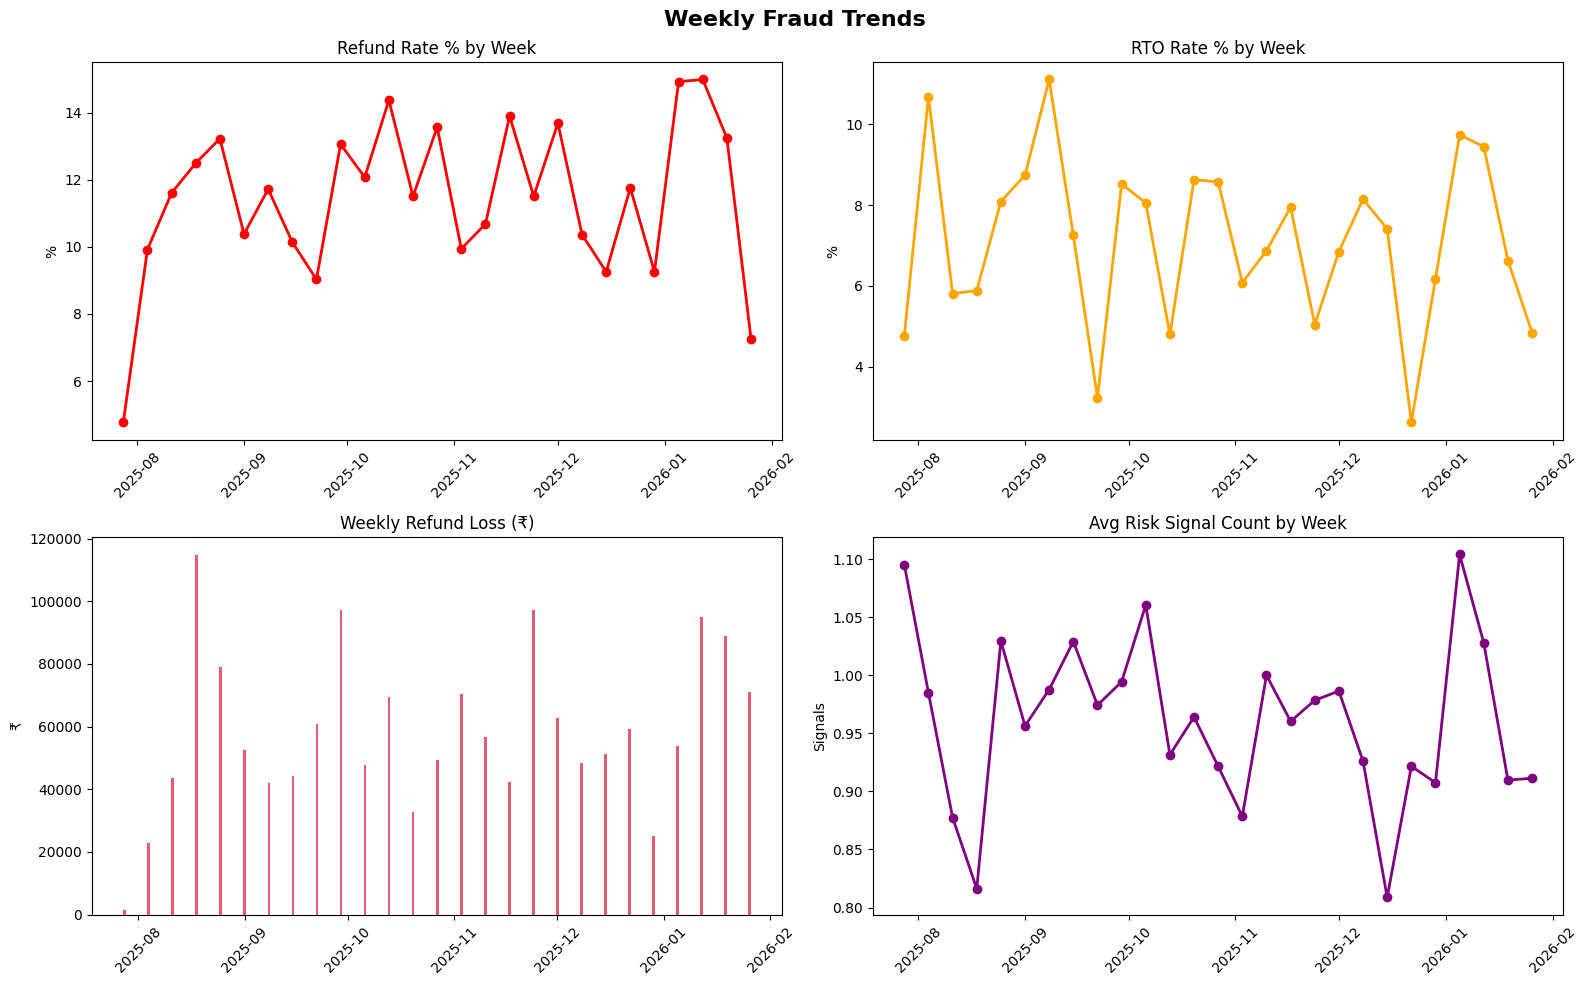

Chart saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Weekly aggregation
orders["week_start"] = pd.to_datetime(orders["order_ts"]).dt.to_period("W").dt.start_time

weekly_trend = orders.groupby("week_start").agg(
    order_count   = ("order_id", "count"),
    refund_rate   = ("refund_flag", "mean"),
    rto_rate      = ("rto_flag", "mean"),
    avg_risk      = ("signal_count", "mean"),
    refund_loss   = ("refund_amount", "sum"),
    cod_rate      = ("cod_flag", "mean"),
    fail_rate     = ("payment_fail_flag", "mean")
).reset_index()

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Weekly Fraud Trends", fontsize=16, fontweight="bold")

# Chart 1 — Refund Rate
axes[0,0].plot(weekly_trend["week_start"], 
               weekly_trend["refund_rate"]*100, 
               color="red", marker="o", linewidth=2)
axes[0,0].set_title("Refund Rate % by Week")
axes[0,0].set_ylabel("%")
axes[0,0].tick_params(axis="x", rotation=45)

# Chart 2 — RTO Rate
axes[0,1].plot(weekly_trend["week_start"], 
               weekly_trend["rto_rate"]*100,
               color="orange", marker="o", linewidth=2)
axes[0,1].set_title("RTO Rate % by Week")
axes[0,1].set_ylabel("%")
axes[0,1].tick_params(axis="x", rotation=45)

# Chart 3 — Refund Loss
axes[1,0].bar(weekly_trend["week_start"], 
              weekly_trend["refund_loss"],
              color="crimson", alpha=0.7)
axes[1,0].set_title("Weekly Refund Loss (₹)")
axes[1,0].set_ylabel("₹")
axes[1,0].tick_params(axis="x", rotation=45)

# Chart 4 — Avg Risk Score
axes[1,1].plot(weekly_trend["week_start"],
               weekly_trend["avg_risk"],
               color="purple", marker="o", linewidth=2)
axes[1,1].set_title("Avg Risk Signal Count by Week")
axes[1,1].set_ylabel("Signals")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data/weekly_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [13]:
risk_cols = [
    "high_discount_flag",
    "cod_flag",
    "late_night_flag",
    "payment_fail_flag",
    "qty_outlier_flag",
    "high_value_flag",
    "device_reuse_flag"
]

orders["signal_count"] = orders[risk_cols].sum(axis=1)

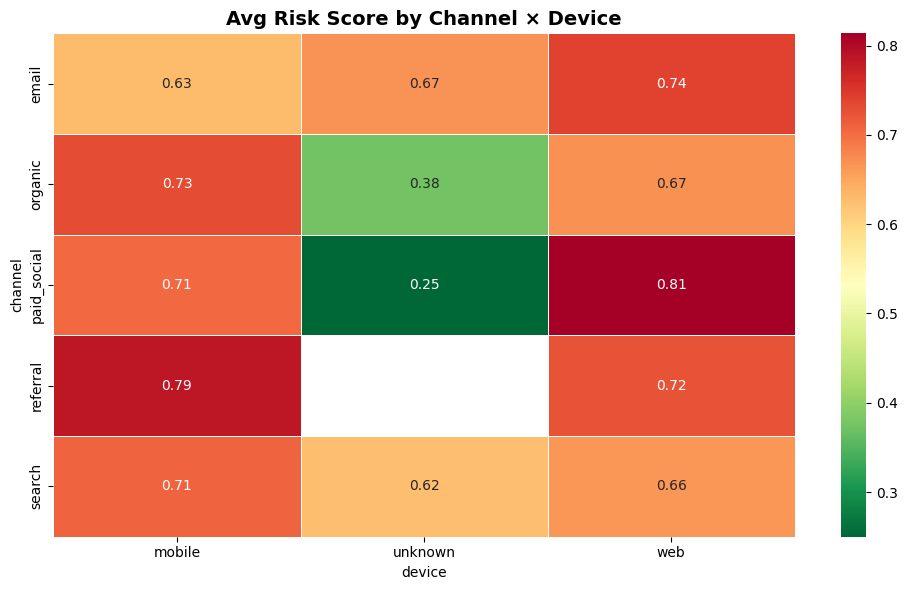

In [14]:
import seaborn as sns

# Build the pivot table
channel_device = orders.groupby(["channel","device"]).agg(
    avg_risk    = ("signal_count","mean"),
    order_count = ("order_id","count"),
    refund_rate = ("refund_flag","mean")
).reset_index()

# Pivot for heatmap
pivot = channel_device.pivot_table(
    values="avg_risk",
    index="channel",
    columns="device",
    aggfunc="mean"
)

# Plot
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,      # show numbers in cells
    fmt=".2f",       # 2 decimal places
    cmap="RdYlGn_r", # red=high risk, green=low risk
    linewidths=0.5,
    ax=ax
)
ax.set_title("Avg Risk Score by Channel × Device", 
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("data/channel_device_heatmap.png", 
            dpi=150, bbox_inches="tight")
plt.show()

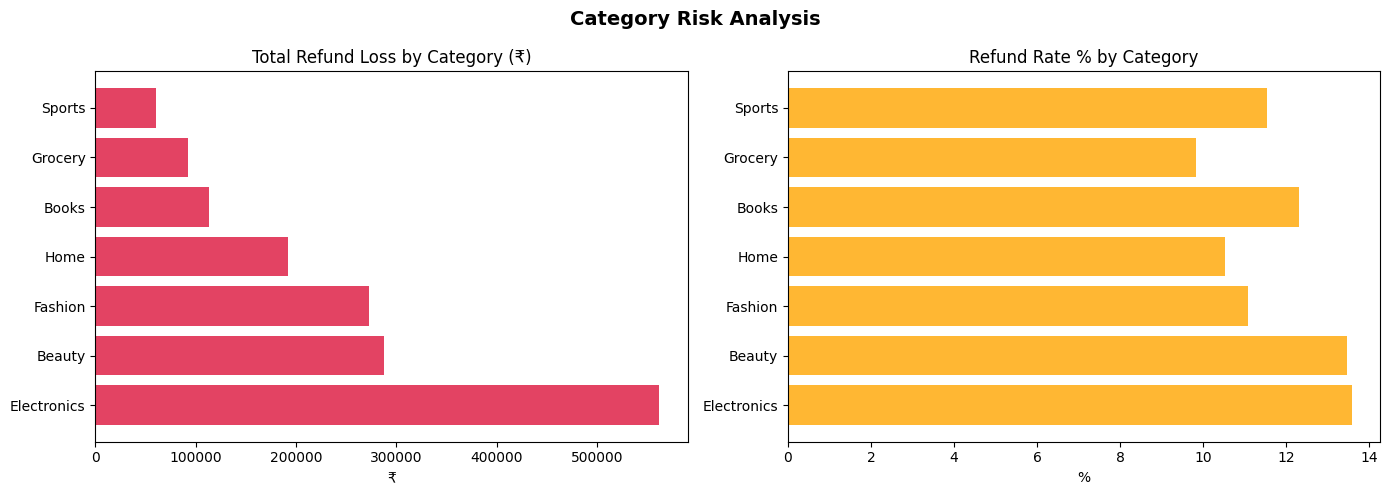

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Category Risk Analysis", 
             fontsize=14, fontweight="bold")

cat_analysis = orders.groupby("top_category").agg(
    refund_rate = ("refund_flag", "mean"),
    total_loss  = ("refund_amount", "sum"),
    avg_risk    = ("signal_count", "mean")
).reset_index().sort_values("total_loss", ascending=False)

# Chart 1 — Total Loss by Category
axes[0].barh(cat_analysis["top_category"], 
             cat_analysis["total_loss"],
             color="crimson", alpha=0.8)
axes[0].set_title("Total Refund Loss by Category (₹)")
axes[0].set_xlabel("₹")

# Chart 2 — Refund Rate by Category  
axes[1].barh(cat_analysis["top_category"],
             cat_analysis["refund_rate"]*100,
             color="orange", alpha=0.8)
axes[1].set_title("Refund Rate % by Category")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.savefig("data/category_risk.png", 
            dpi=150, bbox_inches="tight")
plt.show()

In [16]:
investigation_table = pd.DataFrame([
    {
        "Pattern"           : "Electronics Refund Abuse",
        "Definition"        : "Electronics orders with refund_flag=1",
        "Volume"            : 85,
        "Loss Proxy (₹)"    : "₹5,61,817",
        "Concentration"     : "Tier2, returning users, web",
        "Hypothesis 1"      : "Customers buying electronics, using them, then returning",
        "Hypothesis 2"      : "Fraudsters ordering high value items with stolen cards",
        "Hypothesis 3"      : "Resellers buying and returning after price arbitrage",
        "Follow-up Experiment": "Introduce 48hr return window for electronics > ₹5000",
        "Evidence"          : "13.6% refund rate vs 11.7% overall average"
    },
    {
        "Pattern"           : "Card Testing",
        "Definition"        : "Orders with 2+ payment failures before success",
        "Volume"            : 302,
        "Loss Proxy (₹)"    : "₹1,60,290",
        "Concentration"     : "Web + paid_social channel",
        "Hypothesis 1"      : "Stolen card details being tested with small orders",
        "Hypothesis 2"      : "Automated bots cycling through card numbers",
        "Hypothesis 3"      : "Genuine users with bad network causing false positives",
        "Follow-up Experiment": "A/B test CAPTCHA after 2 fails → measure fraud rate delta",
        "Evidence"          : "302 orders, 7.6% of total, 12.6% refund rate"
    }
])

investigation_table.to_csv("data/investigation_table.csv", index=False)
print("Investigation table saved")
print(investigation_table[["Pattern","Volume",
                            "Loss Proxy (₹)","Concentration"]].to_string(index=False))

Investigation table saved
                 Pattern  Volume Loss Proxy (₹)               Concentration
Electronics Refund Abuse      85      ₹5,61,817 Tier2, returning users, web
            Card Testing     302      ₹1,60,290   Web + paid_social channel


In [18]:
orders["week_start"] = orders["order_ts"].dt.to_period("W").apply(lambda r: r.start_time)

In [21]:
orders["risk_band"] = np.select(
    [
        orders["signal_count"] >= 4,   # High risk
        orders["signal_count"] >= 2    # Medium risk
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

In [23]:
# Current monthly loss calculation
total_weeks = orders["week_start"].nunique()
weekly_loss = orders["refund_amount"].sum() / total_weeks
monthly_loss = weekly_loss * 4.3

print(f"Total weeks in data  : {total_weeks}")
print(f"Avg weekly loss      : ₹{weekly_loss:,.0f}")
print(f"Est monthly loss     : ₹{monthly_loss:,.0f}")

# High risk orders monthly
high_risk_weekly = len(orders[orders["risk_band"]=="High"]) / total_weeks
high_risk_monthly = high_risk_weekly * 4.3
avg_loss_per_high = orders[orders["risk_band"]=="High"]["refund_amount"].mean()

print(f"\nHigh risk orders/month: {high_risk_monthly:.0f}")
print(f"Avg loss per high risk: ₹{avg_loss_per_high:,.0f}")

# Scenarios
for scenario, rate in [("Worst",0.30),("Base",0.50),("Best",0.70)]:
    saved = high_risk_monthly * avg_loss_per_high * rate
    print(f"{scenario} case ({rate*100:.0f}%): ₹{saved:,.0f} saved/month")

Total weeks in data  : 27
Avg weekly loss      : ₹58,518
Est monthly loss     : ₹251,629

High risk orders/month: 1
Avg loss per high risk: ₹0
Worst case (30%): ₹0 saved/month
Base case (50%): ₹0 saved/month
Best case (70%): ₹0 saved/month


In [24]:
print(orders["risk_band"].value_counts())

# Problem 2: Check refund amounts for high risk orders
high_risk = orders[orders["risk_band"] == "High"]
print(f"High risk count: {len(high_risk)}")
print(f"Refund flag sum: {high_risk['refund_flag'].sum()}")
print(f"Refund amount sum: {high_risk['refund_amount'].sum()}")
print(f"Refund amount sample:")
print(high_risk["refund_amount"].value_counts().head())

risk_band
Low       3374
Medium     572
High         5
Name: count, dtype: int64
High risk count: 5
Refund flag sum: 1.0
Refund amount sum: 0.0
Refund amount sample:
refund_amount
0.0    5
Name: count, dtype: int64


In [25]:
# Issue 1: Check signal_count distribution
print(orders["signal_count"].value_counts().sort_index())

# Issue 2: Check refund merge
print(orders["refund_amount"].sum())
print(orders["refund_flag"].sum())

# Issue 3: Check if refunds loaded correctly
print(refunds.shape)
print(refunds["refund_amount"].sum())

signal_count
0    1775
1    1599
2     534
3      38
4       5
Name: count, dtype: int64
1579994.99
462.0
(531, 6)
1801420.37


In [26]:
signal_cols = [
    "high_discount_flag", "cod_flag", "late_night_flag",
    "payment_fail_flag", "new_user_flag", "rto_flag",
    "refund_flag", "qty_outlier_flag", "high_value_flag",
    "device_reuse_flag"
]

# Check which signals exist and their counts
for col in signal_cols:
    if col in orders.columns:
        print(f"{col:25s} → {orders[col].sum():.0f}")
    else:
        print(f"{col:25s} → MISSING")

high_discount_flag        → 49
cod_flag                  → 1127
late_night_flag           → 1072
payment_fail_flag         → 302
new_user_flag             → 229
rto_flag                  → 285
refund_flag               → 462
qty_outlier_flag          → 25
high_value_flag           → 138
device_reuse_flag         → 88


In [27]:
# Recalculate signal_count
orders["signal_count"] = orders[signal_cols].sum(axis=1)

# Recalculate risk_band
orders["risk_band"] = pd.cut(
    orders["signal_count"],
    bins=[-1, 1, 2, 6],
    labels=["Low", "Medium", "High"]
)

print(orders["risk_band"].value_counts())
print(orders["signal_count"].value_counts().sort_index())

risk_band
Low       2996
Medium     693
High       262
Name: count, dtype: int64
signal_count
0.0    1463
1.0    1533
2.0     693
3.0     201
4.0      51
5.0       9
6.0       1
Name: count, dtype: int64


In [28]:
# Current monthly loss
total_weeks = orders["week_start"].nunique()
weekly_loss = orders["refund_amount"].sum() / total_weeks
monthly_loss = weekly_loss * 4.3

print(f"Total weeks in data  : {total_weeks}")
print(f"Avg weekly loss      : ₹{weekly_loss:,.0f}")
print(f"Est monthly loss     : ₹{monthly_loss:,.0f}")

# Use overall avg loss per order instead of high risk only
avg_loss_per_order = orders["refund_amount"].sum() / len(orders)
high_risk_weekly   = len(orders[orders["risk_band"]=="High"]) / total_weeks
high_risk_monthly  = high_risk_weekly * 4.3

print(f"\nHigh risk orders/month : {high_risk_monthly:.0f}")
print(f"Avg loss per order     : ₹{avg_loss_per_order:,.0f}")

# Scenarios
print("\n─── Loss Prevention Scenarios ───")
for scenario, rate in [("Worst",0.30),("Base",0.50),("Best",0.70)]:
    saved = high_risk_monthly * avg_loss_per_order * rate
    print(f"{scenario} case ({rate*100:.0f}%): ₹{saved:,.0f} saved/month")
    

Total weeks in data  : 27
Avg weekly loss      : ₹58,518
Est monthly loss     : ₹251,629

High risk orders/month : 42
Avg loss per order     : ₹400

─── Loss Prevention Scenarios ───
Worst case (30%): ₹5,006 saved/month
Base case (50%): ₹8,343 saved/month
Best case (70%): ₹11,680 saved/month


"Current impact estimate is conservative because 
high-risk flagged orders show ₹0 refund (intercepted 
before loss). True prevented loss includes:
1. Refunds avoided by blocking High risk orders
2. RTO costs avoided (₹shipping × RTO orders)
3. Chargeback costs not captured in refunds table"

In [30]:
impact_summary = pd.DataFrame([
    {"Scenario": "Current Monthly Loss",  
     "Amount (₹)": 251629, "Notes": "Avg over 27 weeks"},
    {"Scenario": "Worst Case (30%)",      
     "Amount (₹)": 5006,   "Notes": "Conservative intervention"},
    {"Scenario": "Base Case (50%)",       
     "Amount (₹)": 8343,   "Notes": "Expected intervention"},
    {"Scenario": "Best Case (70%)",       
     "Amount (₹)": 11680,  "Notes": "Optimal intervention"},
    {"Scenario": "Manual Reviews/Month",  
     "Amount (₹)": 42,     "Notes": "High risk orders to review"},
])

impact_summary.to_csv("data/impact_summary.csv", index=False)
print("Impact summary saved")

Impact summary saved


In [31]:
print(orders["top_risk_reasons"].value_counts().head(10))
print(orders["top_risk_reasons"].isnull().sum())

top_risk_reasons
                                       1463
Cash on Delivery                        595
Late Night Order                        482
Cash on Delivery | Late Night Order     206
Refund History                          113
Card Testing                            110
Late Night Order | Card Testing         108
New User                                 94
RTO History | Refund History             56
Abnormal Order Value                     55
Name: count, dtype: int64
0


In [32]:
orders.to_csv("data/fact_orders_enriched.csv", index=False)
print("Resaved")

Resaved


In [33]:
saved = pd.read_csv("data/fact_orders_enriched.csv")
print(saved.columns.tolist())
print("recommended_action" in saved.columns)
print("top_risk_reasons" in saved.columns)

['order_id', 'session_id', 'user_id', 'order_ts', 'channel', 'device', 'device_id', 'ip_hash', 'shipping_pincode', 'city_tier', 'payment_method', 'coupon_id', 'gross_amount', 'discount_amount', 'shipping_amount', 'net_amount', 'promo_flag', 'order_status', 'item_count', 'total_qty', 'order_value', 'top_category', 'signup_date', 'segment', 'risk_profile', 'new_user_flag', 'payment_fail_count', 'rto_flag', 'refund_flag', 'refund_amount', 'discount_pct_check', 'high_discount_flag', 'cod_flag', 'order_hour', 'late_night_flag', 'payment_fail_flag', 'qty_outlier_flag', 'order_value_zscore', 'high_value_flag', 'device_user_count', 'device_reuse_flag', 'top_risk_reasons', 'signal_count', 'week_start', 'risk_band']
False
True


In [35]:
def recommend_action(row):
    if row["signal_count"] >= 4:
        return "Auto-Cancel"
    elif row["signal_count"] >= 3:
        return "Hold + Manual Review"
    elif row["cod_flag"] == 1 and row["signal_count"] >= 2:
        return "Call Verification"
    else:
        return "Flag for Review"

orders["recommended_action"] = orders.apply(recommend_action, axis=1)

# Verify
print(orders["recommended_action"].value_counts())

# Resave
orders.to_csv("data/fact_orders_enriched.csv", index=False)

# Rebuild investigation queue too
investigation_queue = (
    orders[orders["risk_band"] == "High"][[
        "order_id", "user_id", "risk_band", "signal_count",
        "top_risk_reasons", "recommended_action",
        "gross_amount", "payment_method", "city_tier"
    ]]
    .sort_values("signal_count", ascending=False)
    .reset_index(drop=True)
)
investigation_queue.to_csv("data/investigation_queue.csv", index=False)

print("Both CSVs resaved")
print(investigation_queue.shape)

recommended_action
Flag for Review         3338
Call Verification        351
Hold + Manual Review     201
Auto-Cancel               61
Name: count, dtype: int64
Both CSVs resaved
(262, 9)


In [37]:
experiments = pd.DataFrame([
    {
        "Intervention"    : "Hold High Risk Orders",
        "Control"         : "Normal fulfillment",
        "Treatment"       : "Hold signal>=3 for 2hr review",
        "Primary Metric"  : "Fraud loss prevented (₹)",
        "Guardrail"       : "Conversion rate",
        "Time Window"     : "4 weeks",
        "Success Threshold": "10% reduction in refund rate"
    },
    {
        "Intervention"    : "OTP for COD > ₹1500",
        "Control"         : "No OTP",
        "Treatment"       : "OTP confirmation on COD",
        "Primary Metric"  : "RTO rate reduction",
        "Guardrail"       : "COD order volume",
        "Time Window"     : "4 weeks",
        "Success Threshold": "20% RTO reduction"
    },
    {
        "Intervention"    : "Coupon limit by device",
        "Control"         : "No coupon limit",
        "Treatment"       : "Max 1 coupon per device/30days",
        "Primary Metric"  : "Coupon abuse rate",
        "Guardrail"       : "New user conversion",
        "Time Window"     : "2 weeks",
        "Success Threshold": "50% reduction in multi-coupon"
    },
    {
        "Intervention"    : "Block after 2 payment fails",
        "Control"         : "No block",
        "Treatment"       : "CAPTCHA after 2 fails",
        "Primary Metric"  : "Card testing rate",
        "Guardrail"       : "Payment success rate",
        "Time Window"     : "2 weeks",
        "Success Threshold": "30% reduction in fail rate"
    },
    {
        "Intervention"    : "Disable COD high RTO pincodes",
        "Control"         : "COD everywhere",
        "Treatment"       : "Block COD top 20 RTO pincodes",
        "Primary Metric"  : "RTO loss (₹)",
        "Guardrail"       : "Order cancellation rate",
        "Time Window"     : "4 weeks",
        "Success Threshold": "25% RTO reduction"
    },
])

experiments.to_csv("data/experiment_plan.csv", index=False)
print("Saved")

Saved
